# 🚀 CDS525: FinBERT Experiment 1

## Weighted CrossEntropy - Grid Search

### Hyperparameter Grid:
- **Batch Sizes**: 16, 32, 64, 128
- **Learning Rates**: 1e-6, 2e-5, 5e-5, 1e-4
- **Total Combinations**: 16

### Training Output (per epoch):
- `train_loss`, `train_acc`, `test_loss`, `test_acc`, `f1_score`, `balanced_acc`

### Visualizations Generated:
- Heatmaps (F1, Qualitative Acc, Test Acc)
- Training Loss by Batch Size
- Test Loss by Batch Size
- Training Accuracy by Batch Size
- Test Accuracy by Batch Size
- F1 Score by Batch Size
- Balanced Accuracy by Batch Size
- Combined Metrics Overview

### Estimated Runtime: ~10-14 hours on A100

---

In [1]:
# ============================================================================
# CELL 1: MOUNT DRIVE & INSTALL
# ============================================================================

from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers accelerate

print("✅ Setup complete!")

Mounted at /content/drive
✅ Setup complete!


In [2]:
# ============================================================================
# CELL 2: IMPORTS & CONFIGURATION
# ============================================================================

import os
import gc
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score

# ============================================================================
# PATHS
# ============================================================================

PROJECT_DIR = "/content/drive/MyDrive/CDS525_Project"
OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs_compliant_exp1_test")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Set seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📁 Project: {PROJECT_DIR}")
print(f"📁 Output: {OUTPUT_DIR}")
print(f"🖥️ Device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

📁 Project: /content/drive/MyDrive/CDS525_Project
📁 Output: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test
🖥️ Device: cuda
   GPU: NVIDIA A100-SXM4-40GB
   VRAM: 42.5 GB


In [3]:
# ============================================================================
# CELL 3: ENHANCED CONFIGURATION
# ============================================================================

@dataclass
class Config:
    """Configuration for FinBERT sentiment analysis."""
    model_name: str = "ProsusAI/finbert"
    num_labels: int = 3
    max_length: int = 128

    # DEFAULT TRAINING SETTINGS
    batch_size: int = 32
    learning_rate: float = 3e-5
    num_epochs: int = 15
    weight_decay: float = 0.01
    warmup_ratio: float = 0.1

    # FOCAL LOSS PARAMETERS
    focal_gamma: float = 2.0
    focal_alpha_neg: float = 0.4
    focal_alpha_neu: float = 0.2
    focal_alpha_pos: float = 0.4

    # EARLY STOPPING
    patience: int = 15
    min_delta: float = 0.001

    # Device
    device: str = "cuda" if torch.cuda.is_available() else "cpu"

    # Data files
    twitter_files: List[str] = field(default_factory=lambda: [
        "sent_train.csv", "twitter_financial_news.csv"
    ])
    nifty_files: List[str] = field(default_factory=lambda: [
        "News_sentiment_Jan2017_to_Apr2021.csv", "nifty_news_sentiment.csv"
    ])
    phrasebank_files: List[str] = field(default_factory=lambda: [
        "Sentences_75Agree.txt"
    ])

config = Config()

print("✅ Configuration Loaded:")
print(f"   Model: {config.model_name}")
print(f"   Default LR: {config.learning_rate}")
print(f"   Default Epochs: {config.num_epochs}")
print(f"   Early Stopping Patience: {config.patience}")

✅ Configuration Loaded:
   Model: ProsusAI/finbert
   Default LR: 3e-05
   Default Epochs: 15
   Early Stopping Patience: 15


In [4]:
# ============================================================================
# CELL 4: ENHANCED FOCAL LOSS WITH LABEL SMOOTHING
# ============================================================================

class EnhancedFocalLoss(nn.Module):
    """
    Enhanced Focal Loss for handling class imbalance.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        gamma: Focusing parameter (default: 2.0)
        alpha: Per-class weights tensor
        label_smoothing: Label smoothing factor (default: 0.1)
        reduction: 'mean', 'sum', or 'none'
    """

    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.1, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.reduction = reduction

    def forward(self, inputs, targets):
        # Compute softmax with numerical stability
        p = F.softmax(inputs, dim=1)
        p = p.clamp(min=1e-7, max=1-1e-7)

        # Get probability for true class
        p_t = p.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Compute focal weight
        focal_weight = (1 - p_t) ** self.gamma

        # Compute cross entropy with label smoothing
        ce_loss = F.cross_entropy(
            inputs, targets,
            reduction='none',
            label_smoothing=self.label_smoothing
        )

        # Apply focal weight
        focal_loss = focal_weight * ce_loss

        # Apply class weights
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            alpha_t = alpha.gather(0, targets)
            focal_loss = alpha_t * focal_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

print("✅ EnhancedFocalLoss defined with label smoothing!")

✅ EnhancedFocalLoss defined with label smoothing!


In [5]:
# ============================================================================
# CELL 5: THREE-SOURCE DATA LOADER
# ============================================================================

class ThreeSourceHybridLoader:
    """Load and combine data from three financial sentiment sources."""

    LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    def __init__(self, project_dir):
        self.project_dir = project_dir
        self.texts = []
        self.labels = []
        self.load_stats = {'twitter': 0, 'nifty': 0, 'phrasebank': 0}

    def _find_file(self, candidates):
        for f in candidates:
            path = os.path.join(self.project_dir, f)
            if os.path.exists(path):
                return path
        return None

    def load_twitter(self, files):
        path = self._find_file(files)
        if not path:
            print(f"⚠️ Twitter data not found")
            return 0
        try:
            df = pd.read_csv(path, encoding='latin-1')
            text_col = next((c for c in ['text', 'Text', 'sentence'] if c in df.columns), df.columns[0])
            label_col = next((c for c in ['label', 'Label', 'sentiment'] if c in df.columns), df.columns[-1])
            mapping = {0: 0, 1: 2, 2: 1, '0': 0, '1': 2, '2': 1}
            count = 0
            for _, row in df.iterrows():
                text = str(row[text_col]).strip()
                if pd.isna(text) or text == '' or text == 'nan':
                    continue
                raw = row[label_col]
                if isinstance(raw, float) and not pd.isna(raw):
                    raw = int(raw)
                if raw in mapping:
                    self.texts.append(f"[SOCIAL] {text}")
                    self.labels.append(mapping[raw])
                    count += 1
            self.load_stats['twitter'] = count
            print(f"✅ Twitter [SOCIAL]: {count:,}")
            return count
        except Exception as e:
            print(f"❌ Twitter error: {e}")
            return 0

    def load_nifty(self, files):
        path = self._find_file(files)
        if not path:
            print(f"⚠️ NIFTY data not found")
            return 0
        try:
            df = pd.read_csv(path, encoding='latin-1')
            text_col = next((c for c in ['News', 'news', 'text', 'headline', 'Title'] if c in df.columns), None)
            label_col = next((c for c in ['Sentiment', 'sentiment', 'label'] if c in df.columns), None)
            if not text_col or not label_col:
                return 0
            mapping = {'negative': 0, 'positive': 2, 'neutral': 1}
            count = 0
            for _, row in df.iterrows():
                text = str(row[text_col]).strip()
                if pd.isna(text) or text == '' or text == 'nan':
                    continue
                raw = str(row[label_col]).strip().lower()
                if raw in mapping:
                    self.texts.append(f"[NEWS_IN] {text}")
                    self.labels.append(mapping[raw])
                    count += 1
            self.load_stats['nifty'] = count
            print(f"✅ NIFTY [NEWS_IN]: {count:,}")
            return count
        except Exception as e:
            print(f"❌ NIFTY error: {e}")
            return 0

    def load_phrasebank(self, files):
        path = self._find_file(files)
        if not path:
            print(f"⚠️ PhraseBank not found")
            return 0
        try:
            mapping = {'negative': 0, 'positive': 2, 'neutral': 1}
            count = 0
            with open(path, 'r', encoding='latin-1') as f:
                for line in f:
                    line = line.strip()
                    if '@' in line:
                        parts = line.rsplit('@', 1)
                        if len(parts) == 2:
                            text, label = parts[0].strip(), parts[1].strip().lower()
                            if label in mapping and text:
                                self.texts.append(f"[NEWS_FIN] {text}")
                                self.labels.append(mapping[label])
                                count += 1
            self.load_stats['phrasebank'] = count
            print(f"✅ PhraseBank [NEWS_FIN]: {count:,}")
            return count
        except Exception as e:
            print(f"❌ PhraseBank error: {e}")
            return 0

    def load_all(self, config):
        print("\n📥 Loading all data sources...")
        self.load_twitter(config.twitter_files)
        self.load_nifty(config.nifty_files)
        self.load_phrasebank(config.phrasebank_files)

        total = len(self.texts)
        print(f"\n📊 Total samples: {total:,}")
        print(f"   Sources: Twitter={self.load_stats['twitter']:,}, "
              f"NIFTY={self.load_stats['nifty']:,}, "
              f"PhraseBank={self.load_stats['phrasebank']:,}")

        return self.texts, self.labels

print("✅ ThreeSourceHybridLoader defined!")

✅ ThreeSourceHybridLoader defined!


In [6]:
# ============================================================================
# CELL 6: SENTIMENT DATASET
# ============================================================================

class SentimentDataset(Dataset):
    """PyTorch Dataset for sentiment classification."""

    LABEL_NAMES = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long)
        }

    @classmethod
    def decode_label(cls, idx):
        return cls.LABEL_NAMES.get(idx, 'Unknown')

print("✅ SentimentDataset defined!")

✅ SentimentDataset defined!


In [7]:
# ============================================================================
# CELL 7: TRAINING HISTORY TRACKER
# ============================================================================

@dataclass
class TrainingHistory:
    """Track all metrics during training."""
    train_losses: List[float] = field(default_factory=list)
    train_accs: List[float] = field(default_factory=list)      # Training accuracy
    test_accs: List[float] = field(default_factory=list)       # Test accuracy
    test_losses: List[float] = field(default_factory=list)
    f1_scores: List[float] = field(default_factory=list)
    balanced_accs: List[float] = field(default_factory=list)

    def add(self, train_loss, train_acc, test_acc, test_loss=None, f1=None, bal_acc=None):
        self.train_losses.append(train_loss)
        self.train_accs.append(train_acc)
        self.test_accs.append(test_acc)
        if test_loss is not None:
            self.test_losses.append(test_loss)
        if f1 is not None:
            self.f1_scores.append(f1)
        if bal_acc is not None:
            self.balanced_accs.append(bal_acc)

print("✅ TrainingHistory defined!")

✅ TrainingHistory defined!


In [8]:
# ============================================================================
# CELL 8: TRAINING FUNCTION WITH EARLY STOPPING
# ============================================================================

def train_model_enhanced(
    model, train_loader, test_loader, config,
    loss_fn=None, lr=None, num_epochs=None, name="Experiment",
    use_early_stopping=True
):
    """
    Train model with comprehensive metric tracking.

    Returns:
        model: Trained model
        history: TrainingHistory with all metrics
    """
    learning_rate = lr or config.learning_rate
    epochs = num_epochs or config.num_epochs
    loss_fn = loss_fn or nn.CrossEntropyLoss()

    device = torch.device(config.device)
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=config.weight_decay
    )

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * config.warmup_ratio),
        num_training_steps=total_steps
    )

    history = TrainingHistory()
    best_f1 = 0
    best_model_state = None
    patience_counter = 0

    print(f"\n{'='*60}")
    print(f"🚀 {name}")
    print(f"   LR: {learning_rate}, Loss: {type(loss_fn).__name__}")
    print(f"   Epochs: {epochs}, Early Stopping: {use_early_stopping}")
    print(f"{'='*60}")

    for epoch in range(epochs):
        # ==================== TRAINING ====================
        model.train()
        total_loss, correct, total = 0, 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100*correct/total:.2f}%'})

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ==================== EVALUATION ====================
        model.eval()
        all_preds, all_labels = [], []
        test_loss_sum = 0

        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]"):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = loss_fn(logits, labels)
                test_loss_sum += loss.item()

                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        test_loss = test_loss_sum / len(test_loader)
        test_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
        macro_f1 = 100 * f1_score(all_labels, all_preds, average='macro')
        bal_acc = 100 * balanced_accuracy_score(all_labels, all_preds)

        # Record metrics
        history.add(train_loss, train_acc, test_acc, test_loss, macro_f1, bal_acc)

        print(f"\n📊 Epoch {epoch+1}: Train Loss={train_loss:.4f}, "
              f"Train Acc={train_acc:.2f}%, Test Acc={test_acc:.2f}%, "
              f"F1={macro_f1:.2f}%")

        # Early stopping based on F1
        if macro_f1 > best_f1 + config.min_delta:
            best_f1 = macro_f1
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"   ✨ New best F1: {macro_f1:.2f}%")
        else:
            patience_counter += 1
            if use_early_stopping and patience_counter >= config.patience:
                print(f"\n⏹️ Early stopping at epoch {epoch+1}")
                break

    # Restore best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Restored best model (F1={best_f1:.2f}%)")

    return model, history

print("✅ Training function defined!")

✅ Training function defined!


In [9]:
# ============================================================================
# CELL 9: DATA LOADER CREATION
# ============================================================================

def create_loaders_enhanced(
    texts, labels, tokenizer,
    batch_size=32, max_length=128, test_size=0.2,
    use_weighted_sampling=False
):
    """Create train and test data loaders."""
    train_texts, test_texts, train_labels, test_labels = train_test_split(
        texts, labels, test_size=test_size, random_state=42, stratify=labels
    )

    train_ds = SentimentDataset(train_texts, train_labels, tokenizer, max_length)
    test_ds = SentimentDataset(test_texts, test_labels, tokenizer, max_length)

    if use_weighted_sampling:
        class_counts = np.bincount(train_labels, minlength=3)
        weights = 1.0 / class_counts
        sample_weights = [weights[label] for label in train_labels]
        sampler = WeightedRandomSampler(sample_weights, len(sample_weights))
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, sampler=sampler,
            num_workers=2, pin_memory=True
        )
    else:
        train_loader = DataLoader(
            train_ds, batch_size=batch_size, shuffle=True,
            num_workers=2, pin_memory=True
        )

    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False,
        num_workers=2, pin_memory=True
    )

    print(f"   Train: {len(train_ds):,} | Test: {len(test_ds):,} | Batch: {batch_size}")
    return train_loader, test_loader, test_texts, test_labels

print("✅ Data loader function defined!")

✅ Data loader function defined!


In [10]:
# ============================================================================
# CELL 10: VISUALIZATION FUNCTIONS (FULLY COMPLIANT)
# ============================================================================

def plot_single_experiment(history, title, save_path):
    """
    Plot training results for a single experiment.
    Shows: Training Loss, Training Accuracy, Test Accuracy (as required)
    """
    epochs = range(1, len(history.train_losses) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Subplot 1: Loss
    axes[0].plot(epochs, history.train_losses, 'b-o', lw=2, ms=8, label='Train Loss')
    if history.test_losses:
        axes[0].plot(epochs, history.test_losses, 'r--s', lw=2, ms=8, label='Test Loss')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training & Test Loss', fontsize=12)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Subplot 2: Accuracy (BOTH train and test as required)
    axes[1].plot(epochs, history.train_accs, 'b-o', lw=2, ms=8, label='Train Accuracy')
    axes[1].plot(epochs, history.test_accs, 'g-^', lw=2, ms=8, label='Test Accuracy')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_title('Training & Test Accuracy', fontsize=12)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Subplot 3: F1 Score
    if history.f1_scores:
        axes[2].plot(epochs, history.f1_scores, 'm-o', lw=2, ms=8, label='Macro F1')
    if history.balanced_accs:
        axes[2].plot(epochs, history.balanced_accs, 'c-s', lw=2, ms=8, label='Balanced Acc')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Score (%)', fontsize=12)
    axes[2].set_title('F1 & Balanced Accuracy', fontsize=12)
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Saved: {save_path}")
    plt.show()


def plot_loss_function_comparison(h1, h2, title, save_path):
    """
    Compare two loss functions.
    Shows: Training Loss, Training Accuracy, Test Accuracy (as required)
    """
    max_epochs = max(len(h1.train_losses), len(h2.train_losses))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Train Loss
    e1 = range(1, len(h1.train_losses) + 1)
    e2 = range(1, len(h2.train_losses) + 1)
    axes[0].plot(e1, h1.train_losses, 'b-o', lw=2, ms=8, label='CrossEntropy')
    axes[0].plot(e2, h2.train_losses, 'r-s', lw=2, ms=8, label='Focal Loss')
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Train Loss', fontsize=12)
    axes[0].set_title('Training Loss', fontsize=12)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Train Accuracy
    axes[1].plot(e1, h1.train_accs, 'b-o', lw=2, ms=8, label='CrossEntropy')
    axes[1].plot(e2, h2.train_accs, 'r-s', lw=2, ms=8, label='Focal Loss')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Train Accuracy (%)', fontsize=12)
    axes[1].set_title('Training Accuracy', fontsize=12)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # Test Accuracy
    axes[2].plot(e1, h1.test_accs, 'b-o', lw=2, ms=8, label='CrossEntropy')
    axes[2].plot(e2, h2.test_accs, 'r-s', lw=2, ms=8, label='Focal Loss')
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('Test Accuracy (%)', fontsize=12)
    axes[2].set_title('Test Accuracy', fontsize=12)
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Saved: {save_path}")
    plt.show()


def plot_hyperparam_study_figure1(histories, param_name, save_path):
    """
    FIGURE 1 for hyperparameter study: Training Loss over epochs.
    Requirement: "Training loss ... with the change of number of epochs"
    """
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    markers = ['o', 's', '^', 'D', 'v']

    fig, ax = plt.subplots(figsize=(10, 6))
    fig.suptitle(f'{param_name} Study - Training Loss', fontsize=14, fontweight='bold')

    for i, (param, h) in enumerate(histories.items()):
        c, m = colors[i % len(colors)], markers[i % len(markers)]
        epochs = range(1, len(h.train_losses) + 1)
        ax.plot(epochs, h.train_losses, color=c, marker=m, lw=2, ms=8,
                label=f'{param_name}={param}')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Training Loss', fontsize=12)
    ax.set_title(f'Training Loss vs Epochs ({param_name} Comparison)', fontsize=12)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Saved: {save_path}")
    plt.show()


def plot_hyperparam_study_figure2(histories, param_name, save_path):
    """
    FIGURE 2 for hyperparameter study: Training Accuracy AND Test Accuracy.
    Requirement: "training accuracy, and test accuracy with the change of number of epochs"
    """
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    markers = ['o', 's', '^', 'D', 'v']

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{param_name} Study - Accuracy Comparison', fontsize=14, fontweight='bold')

    # Subplot 1: Training Accuracy
    for i, (param, h) in enumerate(histories.items()):
        c, m = colors[i % len(colors)], markers[i % len(markers)]
        epochs = range(1, len(h.train_accs) + 1)
        axes[0].plot(epochs, h.train_accs, color=c, marker=m, lw=2, ms=8,
                     label=f'{param_name}={param}')

    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Training Accuracy (%)', fontsize=12)
    axes[0].set_title('Training Accuracy vs Epochs', fontsize=12)
    axes[0].legend(loc='best')
    axes[0].grid(alpha=0.3)

    # Subplot 2: Test Accuracy
    for i, (param, h) in enumerate(histories.items()):
        c, m = colors[i % len(colors)], markers[i % len(markers)]
        epochs = range(1, len(h.test_accs) + 1)
        axes[1].plot(epochs, h.test_accs, color=c, marker=m, lw=2, ms=8,
                     label=f'{param_name}={param}')

    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Test Accuracy (%)', fontsize=12)
    axes[1].set_title('Test Accuracy vs Epochs', fontsize=12)
    axes[1].legend(loc='best')
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Saved: {save_path}")
    plt.show()


print("✅ All visualization functions defined (COMPLIANT with requirements)!")

✅ All visualization functions defined (COMPLIANT with requirements)!


In [11]:
# ============================================================================
# CELL 11: QUALITATIVE ANALYSIS (First 100 predictions)
# ============================================================================

def qualitative_analysis(model, test_texts, test_labels, tokenizer, config, num=100, save_path=None):
    """
    Analyze first 100 predictions with inputs, actual labels, and predicted labels.
    Requirement: "Visualize your predicted labels together with their corresponding
                  inputs and actual labels of the first 100 results in the test set"
    """
    device = torch.device(config.device)
    model = model.to(device)
    model.eval()

    results = []
    with torch.no_grad():
        for i in tqdm(range(min(num, len(test_texts))), desc="Predicting first 100"):
            text = test_texts[i]
            enc = tokenizer(text, max_length=config.max_length, padding='max_length',
                          truncation=True, return_tensors='pt')

            outputs = model(enc['input_ids'].to(device),
                          attention_mask=enc['attention_mask'].to(device))
            probs = F.softmax(outputs.logits, dim=1).cpu().numpy()[0]
            pred = np.argmax(probs)

            results.append({
                'Index': i + 1,
                'Input Text': text[:100] + '...' if len(text) > 100 else text,
                'Actual Label': SentimentDataset.decode_label(test_labels[i]),
                'Predicted Label': SentimentDataset.decode_label(pred),
                'Confidence': f'{max(probs)*100:.1f}%',
                'Correct': '✓' if test_labels[i] == pred else '✗'
            })

    df = pd.DataFrame(results)
    correct = sum(1 for r in results if r['Correct'] == '✓')
    print(f"\n📋 Accuracy on first {num} samples: {100*correct/len(results):.2f}%")

    if save_path:
        df.to_csv(save_path, index=False)
        print(f"💾 Saved: {save_path}")

    # Display first 20 rows
    display(df.head(20))
    return df


def plot_qualitative_figure(df, save_path):
    """
    Create a visual figure for qualitative analysis.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Qualitative Analysis: First 100 Test Predictions', fontsize=14, fontweight='bold')

    # Confusion breakdown
    correct_counts = df.groupby(['Actual Label', 'Correct']).size().unstack(fill_value=0)
    if '✓' in correct_counts.columns and '✗' in correct_counts.columns:
        correct_counts[['✓', '✗']].plot(kind='bar', ax=axes[0], color=['green', 'red'])
    axes[0].set_xlabel('Actual Label', fontsize=12)
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Correct vs Incorrect by Class', fontsize=12)
    axes[0].legend(['Correct', 'Incorrect'])
    axes[0].tick_params(axis='x', rotation=0)

    # Prediction distribution
    pred_counts = df['Predicted Label'].value_counts()
    actual_counts = df['Actual Label'].value_counts()
    x = np.arange(len(pred_counts))
    width = 0.35
    axes[1].bar(x - width/2, [actual_counts.get(l, 0) for l in pred_counts.index],
                width, label='Actual', color='steelblue')
    axes[1].bar(x + width/2, pred_counts.values, width, label='Predicted', color='coral')
    axes[1].set_xlabel('Sentiment Label', fontsize=12)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Actual vs Predicted Distribution', fontsize=12)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(pred_counts.index)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"📊 Saved: {save_path}")
    plt.show()


print("✅ Qualitative analysis functions defined!")

✅ Qualitative analysis functions defined!


In [12]:
# ============================================================================
# CELL 12: GPU MEMORY MANAGEMENT
# ============================================================================

def clear_gpu():
    """Clear GPU memory."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()
    print("🧹 GPU memory cleared")

print("✅ GPU management ready!")

✅ GPU management ready!


---
# 🚀 EXPERIMENT 1: WEIGHTED CROSSENTROPY GRID SEARCH

### Training Output Format (per epoch):
```
Epoch   Train Loss  Train Acc   Test Loss   Test Acc    F1 Score    Bal Acc
--------------------------------------------------------------------------------
1       0.4523      78.45       0.3421      82.31       81.25       80.98
```

---

In [13]:
# ============================================================================
# CELL 13: LOAD DATA
# ============================================================================

print("\n" + "="*80)
print("📥 LOADING DATA")
print("="*80)

tokenizer = AutoTokenizer.from_pretrained(config.model_name)
print("✅ Tokenizer loaded!")

loader = ThreeSourceHybridLoader(PROJECT_DIR)
texts, labels = loader.load_all(config)

# Class distribution
print("\n📊 Class Distribution:")
for i, name in SentimentDataset.LABEL_NAMES.items():
    count = labels.count(i)
    print(f"   {name}: {count:,} ({100*count/len(labels):.1f}%)")

# Calculate alpha weights for Focal Loss
focal_alpha = torch.tensor([
    config.focal_alpha_neg,   # Negative
    config.focal_alpha_neu,   # Neutral
    config.focal_alpha_pos    # Positive
], dtype=torch.float32)
print(f"\n⚖️ Focal Loss alpha: {focal_alpha.tolist()}")

# Calculate weights for Weighted CrossEntropy
class_counts = np.bincount(labels, minlength=3)
ce_weights = torch.tensor(
    [len(labels) / (3 * c) for c in class_counts],
    dtype=torch.float32
)
print(f"⚖️ Weighted CE weights: {[f'{w:.3f}' for w in ce_weights.tolist()]}")


📥 LOADING DATA


tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Tokenizer loaded!

📥 Loading all data sources...
✅ Twitter [SOCIAL]: 9,543
✅ NIFTY [NEWS_IN]: 200,500
✅ PhraseBank [NEWS_FIN]: 3,453

📊 Total samples: 213,496
   Sources: Twitter=9,543, NIFTY=200,500, PhraseBank=3,453

📊 Class Distribution:
   Negative: 109,980 (51.5%)
   Neutral: 8,324 (3.9%)
   Positive: 95,192 (44.6%)

⚖️ Focal Loss alpha: [0.4000000059604645, 0.20000000298023224, 0.4000000059604645]
⚖️ Weighted CE weights: ['0.647', '8.549', '0.748']



🧪 EXPERIMENT 1: WEIGHTED CROSSENTROPY - GRID SEARCH
📁 Models will be saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_models

📊 Batch Sizes: [128]
📊 Learning Rates: [1e-06, 2e-05, 5e-05, 0.0001]
📊 Total Combinations: 4

🔄 Combination 1/4: Batch Size=128, LR=1e-06
🧹 GPU memory cleared
   Train: 170,796 | Test: 42,700 | Batch: 128


pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]


🚀 Training: WeightedCE_BS128_LR1e-06
   LR: 1e-06, Epochs: 15, Early Stopping: True

Epoch   Train Loss  Train Acc   Test Loss   Test Acc    F1 Score    Bal Acc     
--------------------------------------------------------------------------------


Epoch 1/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

...

15      0.2240      87.24       0.2426      86.46       87.04       90.25       

✅ Restored best model (F1=87.10%)
💾 Model saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_models/exp1_model_BS128_LR1e-06
📁 History saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_history_BS128_LR1e-06.csv

📋 Running Qualitative Analysis (First 100 predictions)...


Predicting first 100:   0%|          | 0/100 [00:00<?, ?it/s]


📋 Accuracy on first 100 samples: 89.00%
💾 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR1e-06.csv


,Index,Input Text,Actual Label,Predicted Label,Confidence,Correct
0,1,[NEWS_IN] HUL shares block deal helps FPI inve...,Positive,Positive,90.2%,✓
1,2,[NEWS_IN] Rupee skids 13 paise to 73 . 51 per ...,Negative,Negative,99.3%,✓
2,3,[NEWS_IN] India poised to be counted among top...,Positive,Positive,99.5%,✓
3,4,[SOCIAL] Kohl's stock price target cut to $48 ...,Negative,Negative,71.1%,✓
4,5,[NEWS_IN] Economics of climate change win Nobe...,Positive,Positive,98.2%,✓
5,6,[NEWS_IN] SEBI allows acceptance of client sec...,Negative,Positive,67.9%,✗
6,7,[NEWS_IN] Coronavirus fallout : Why small fina...,Negative,Negative,98.6%,✓
7,8,"[NEWS_IN] Sensex , Nifty start budget week on ...",Positive,Positive,98.7%,✓
8,9,[NEWS_IN] News highlights of the day : Firms w...,Positive,Positive,94.2%,✓
9,10,"[NEWS_IN] Modi to focus on infra spending , be...",Negative,Negative,99.2%,✓


📊 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR1e-06.png


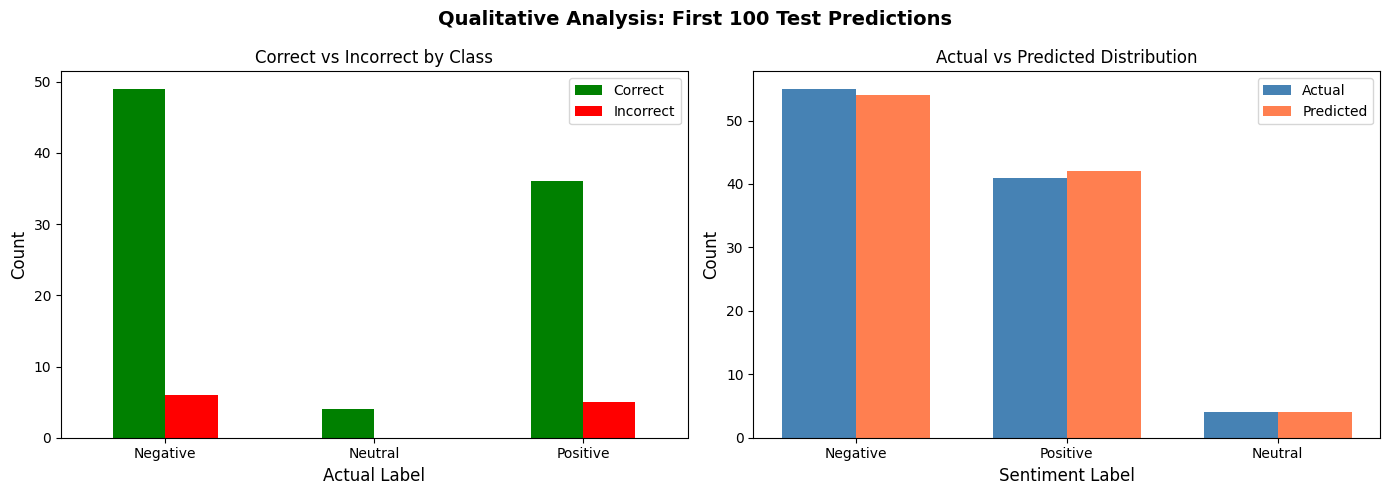


✅ BS128_LR1e-06: Test Acc=86.46%, Best F1=87.10%, Qual-100 Acc=89.00%
🧹 GPU memory cleared

🔄 Combination 2/4: Batch Size=128, LR=2e-05
🧹 GPU memory cleared
   Train: 170,796 | Test: 42,700 | Batch: 128

🚀 Training: WeightedCE_BS128_LR2e-05
   LR: 2e-05, Epochs: 15, Early Stopping: True

Epoch   Train Loss  Train Acc   Test Loss   Test Acc    F1 Score    Bal Acc     
--------------------------------------------------------------------------------


Epoch 1/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

Epoch 1/15 [Test]:   0%|          | 0/334 [00:00<?, ?it/s]

1       0.5210      73.63       0.2640      84.30       84.51       89.07       
         ✨ New best F1: 84.51%


Epoch 2/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

...

15      0.0083      99.65       0.6595      88.88       89.91       90.02       

✅ Restored best model (F1=89.92%)
💾 Model saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_models/exp1_model_BS128_LR2e-05
📁 History saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_history_BS128_LR2e-05.csv

📋 Running Qualitative Analysis (First 100 predictions)...


Predicting first 100:   0%|          | 0/100 [00:00<?, ?it/s]


📋 Accuracy on first 100 samples: 90.00%
💾 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR2e-05.csv


,Index,Input Text,Actual Label,Predicted Label,Confidence,Correct
0,1,[NEWS_IN] HUL shares block deal helps FPI inve...,Positive,Positive,100.0%,✓
1,2,[NEWS_IN] Rupee skids 13 paise to 73 . 51 per ...,Negative,Negative,100.0%,✓
2,3,[NEWS_IN] India poised to be counted among top...,Positive,Positive,100.0%,✓
3,4,[SOCIAL] Kohl's stock price target cut to $48 ...,Negative,Negative,100.0%,✓
4,5,[NEWS_IN] Economics of climate change win Nobe...,Positive,Positive,100.0%,✓
5,6,[NEWS_IN] SEBI allows acceptance of client sec...,Negative,Negative,100.0%,✓
6,7,[NEWS_IN] Coronavirus fallout : Why small fina...,Negative,Negative,100.0%,✓
7,8,"[NEWS_IN] Sensex , Nifty start budget week on ...",Positive,Positive,100.0%,✓
8,9,[NEWS_IN] News highlights of the day : Firms w...,Positive,Positive,100.0%,✓
9,10,"[NEWS_IN] Modi to focus on infra spending , be...",Negative,Negative,100.0%,✓


📊 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR2e-05.png


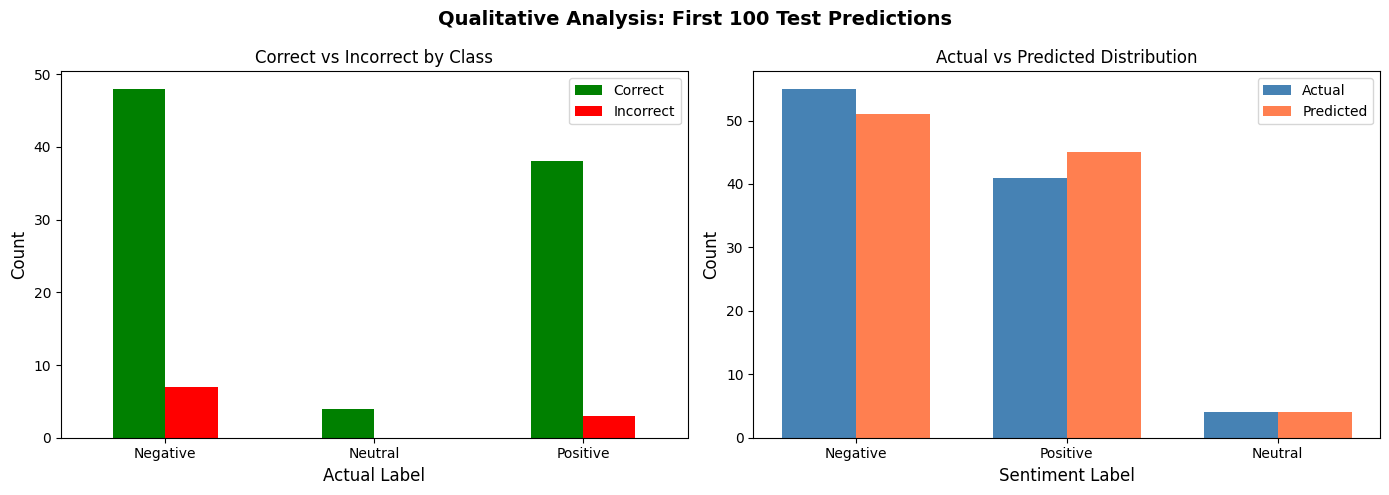


✅ BS128_LR2e-05: Test Acc=88.88%, Best F1=89.92%, Qual-100 Acc=90.00%
🧹 GPU memory cleared

🔄 Combination 3/4: Batch Size=128, LR=5e-05
🧹 GPU memory cleared
   Train: 170,796 | Test: 42,700 | Batch: 128

🚀 Training: WeightedCE_BS128_LR5e-05
   LR: 5e-05, Epochs: 15, Early Stopping: True

Epoch   Train Loss  Train Acc   Test Loss   Test Acc    F1 Score    Bal Acc     
--------------------------------------------------------------------------------


Epoch 1/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

Epoch 1/15 [Test]:   0%|          | 0/334 [00:00<?, ?it/s]

1       0.4318      77.33       0.2489      85.53       85.03       89.94       
         ✨ New best F1: 85.03%


Epoch 2/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

...

15      0.0021      99.92       0.7654      88.46       89.67       90.14       
         ✨ New best F1: 89.67%

✅ Restored best model (F1=89.67%)
💾 Model saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_models/exp1_model_BS128_LR5e-05
📁 History saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_history_BS128_LR5e-05.csv

📋 Running Qualitative Analysis (First 100 predictions)...


Predicting first 100:   0%|          | 0/100 [00:00<?, ?it/s]


📋 Accuracy on first 100 samples: 91.00%
💾 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR5e-05.csv


,Index,Input Text,Actual Label,Predicted Label,Confidence,Correct
0,1,[NEWS_IN] HUL shares block deal helps FPI inve...,Positive,Positive,100.0%,✓
1,2,[NEWS_IN] Rupee skids 13 paise to 73 . 51 per ...,Negative,Negative,100.0%,✓
2,3,[NEWS_IN] India poised to be counted among top...,Positive,Positive,100.0%,✓
3,4,[SOCIAL] Kohl's stock price target cut to $48 ...,Negative,Negative,100.0%,✓
4,5,[NEWS_IN] Economics of climate change win Nobe...,Positive,Positive,100.0%,✓
5,6,[NEWS_IN] SEBI allows acceptance of client sec...,Negative,Negative,100.0%,✓
6,7,[NEWS_IN] Coronavirus fallout : Why small fina...,Negative,Negative,100.0%,✓
7,8,"[NEWS_IN] Sensex , Nifty start budget week on ...",Positive,Positive,100.0%,✓
8,9,[NEWS_IN] News highlights of the day : Firms w...,Positive,Positive,100.0%,✓
9,10,"[NEWS_IN] Modi to focus on infra spending , be...",Negative,Negative,100.0%,✓


📊 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR5e-05.png


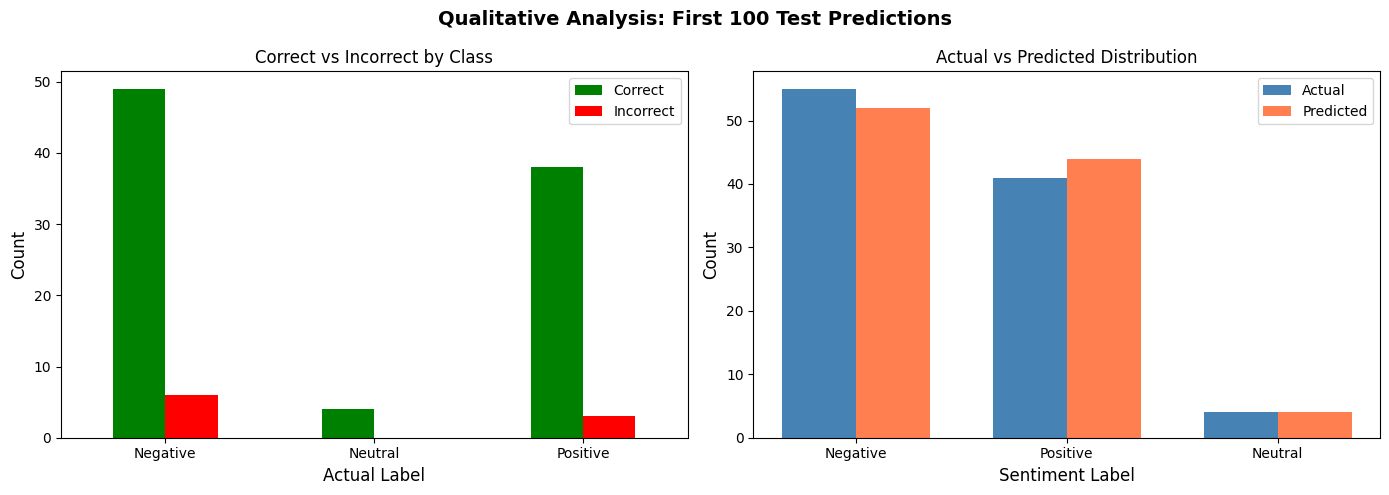


✅ BS128_LR5e-05: Test Acc=88.46%, Best F1=89.67%, Qual-100 Acc=91.00%
🧹 GPU memory cleared

🔄 Combination 4/4: Batch Size=128, LR=0.0001
🧹 GPU memory cleared
   Train: 170,796 | Test: 42,700 | Batch: 128

🚀 Training: WeightedCE_BS128_LR0.0001
   LR: 0.0001, Epochs: 15, Early Stopping: True

Epoch   Train Loss  Train Acc   Test Loss   Test Acc    F1 Score    Bal Acc     
--------------------------------------------------------------------------------


Epoch 1/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

Epoch 1/15 [Test]:   0%|          | 0/334 [00:00<?, ?it/s]

1       0.3949      78.98       0.2541      85.51       85.42       89.55       
         ✨ New best F1: 85.42%


Epoch 2/15 [Train]:   0%|          | 0/1335 [00:00<?, ?it/s]

...

15      0.0013      99.95       0.9354      87.40       88.43       88.75       

✅ Restored best model (F1=88.55%)
💾 Model saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_models/exp1_model_BS128_LR0.0001
📁 History saved to: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_history_BS128_LR0.0001.csv

📋 Running Qualitative Analysis (First 100 predictions)...


Predicting first 100:   0%|          | 0/100 [00:00<?, ?it/s]


📋 Accuracy on first 100 samples: 89.00%
💾 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR0.0001.csv


,Index,Input Text,Actual Label,Predicted Label,Confidence,Correct
0,1,[NEWS_IN] HUL shares block deal helps FPI inve...,Positive,Positive,100.0%,✓
1,2,[NEWS_IN] Rupee skids 13 paise to 73 . 51 per ...,Negative,Negative,100.0%,✓
2,3,[NEWS_IN] India poised to be counted among top...,Positive,Positive,100.0%,✓
3,4,[SOCIAL] Kohl's stock price target cut to $48 ...,Negative,Negative,100.0%,✓
4,5,[NEWS_IN] Economics of climate change win Nobe...,Positive,Positive,100.0%,✓
5,6,[NEWS_IN] SEBI allows acceptance of client sec...,Negative,Negative,100.0%,✓
6,7,[NEWS_IN] Coronavirus fallout : Why small fina...,Negative,Negative,100.0%,✓
7,8,"[NEWS_IN] Sensex , Nifty start budget week on ...",Positive,Positive,100.0%,✓
8,9,[NEWS_IN] News highlights of the day : Firms w...,Positive,Positive,99.9%,✓
9,10,"[NEWS_IN] Modi to focus on infra spending , be...",Negative,Negative,100.0%,✓


📊 Saved: /content/drive/MyDrive/CDS525_Project/outputs_compliant_exp1_test/exp1_qualitative_BS128_LR0.0001.png


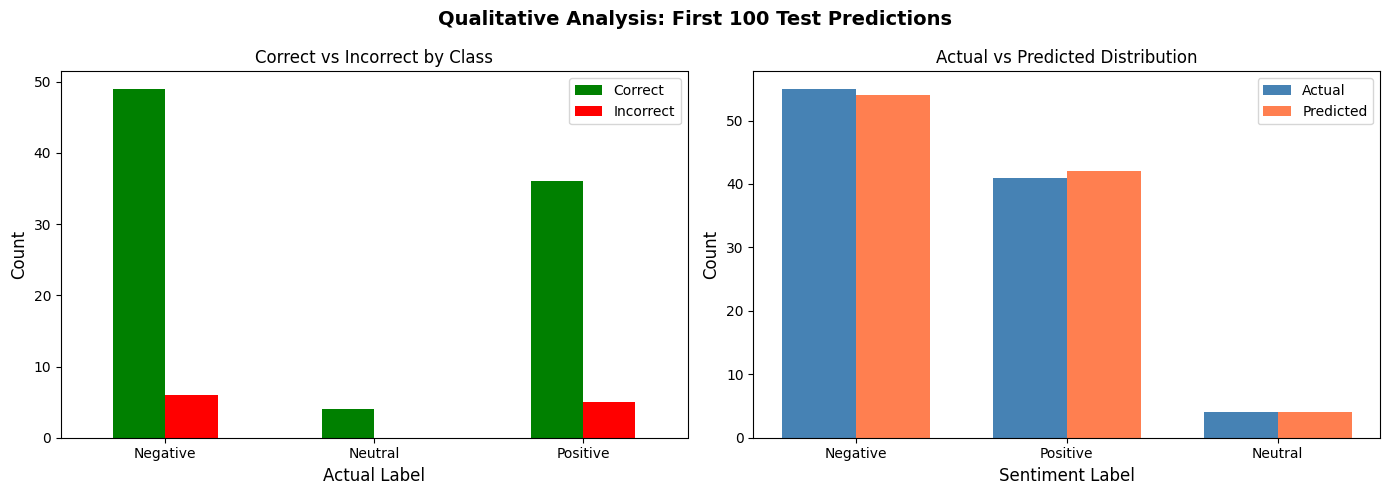


✅ BS128_LR0.0001: Test Acc=87.40%, Best F1=88.55%, Qual-100 Acc=89.00%
🧹 GPU memory cleared

📊 GRID SEARCH COMPLETE - GENERATING VISUALIZATIONS

✅ All training history saved to: exp1_all_training_history.csv


In [14]:
# ============================================================================
# EXPERIMENT 1: WEIGHTED CROSSENTROPY - GRID SEARCH
# Batch Sizes: 16, 32, 64, 128
# Learning Rates: 1e-6, 2e-5, 5e-5, 1e-4
# Total Combinations: 16
# Features: Save models, Save history CSV, Run qualitative analysis (100 tests)
# ============================================================================

print("\n" + "="*80)
print("🧪 EXPERIMENT 1: WEIGHTED CROSSENTROPY - GRID SEARCH")
print("="*80)

# Create model save directory
MODEL_DIR = os.path.join(OUTPUT_DIR, 'exp1_models')
os.makedirs(MODEL_DIR, exist_ok=True)
print(f"📁 Models will be saved to: {MODEL_DIR}")

# Define hyperparameter grid
batch_sizes = [128]
learning_rates = [1e-6,2e-5,5e-5,1e-4]

print(f"\n📊 Batch Sizes: {batch_sizes}")
print(f"📊 Learning Rates: {learning_rates}")
print(f"📊 Total Combinations: {len(batch_sizes) * len(learning_rates)}")

# Store all results
all_results = {}
all_histories = {}
all_qualitative_results = {}

# Custom training function with detailed output
def train_model_detailed(model, train_loader, test_loader, config, loss_fn, lr, name, use_early_stopping=True):
    """Training function with detailed epoch-by-epoch output."""
    device = torch.device(config.device)
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=config.weight_decay)
    total_steps = len(train_loader) * config.num_epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=int(total_steps * config.warmup_ratio), num_training_steps=total_steps
    )

    history = TrainingHistory()
    best_f1 = 0
    best_model_state = None
    patience_counter = 0
    epochs = config.num_epochs

    print(f"\n{'='*70}")
    print(f"🚀 Training: {name}")
    print(f"   LR: {lr}, Epochs: {epochs}, Early Stopping: {use_early_stopping}")
    print(f"{'='*70}")
    print(f"\n{'Epoch':<8}{'Train Loss':<12}{'Train Acc':<12}{'Test Loss':<12}{'Test Acc':<12}{'F1 Score':<12}{'Bal Acc':<12}")
    print("-" * 80)

    for epoch in range(epochs):
        # ==================== TRAINING ====================
        model.train()
        total_loss = 0
        correct = 0
        total = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            loss = loss_fn(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = total_loss / len(train_loader)
        train_acc = 100 * correct / total

        # ==================== EVALUATION ====================
        model.eval()
        all_preds, all_labels = [], []
        test_loss_sum = 0

        with torch.no_grad():
            for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{epochs} [Test]", leave=False):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels_batch = batch['labels'].to(device)

                outputs = model(input_ids, attention_mask=attention_mask)
                logits = outputs.logits
                loss = loss_fn(logits, labels_batch)
                test_loss_sum += loss.item()

                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels_batch.cpu().numpy())

        test_loss = test_loss_sum / len(test_loader)
        test_acc = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
        macro_f1 = 100 * f1_score(all_labels, all_preds, average='macro')
        bal_acc = 100 * balanced_accuracy_score(all_labels, all_preds)

        # Record metrics
        history.add(train_loss, train_acc, test_acc, test_loss, macro_f1, bal_acc)

        # Print detailed metrics for this epoch
        print(f"{epoch+1:<8}{train_loss:<12.4f}{train_acc:<12.2f}{test_loss:<12.4f}{test_acc:<12.2f}{macro_f1:<12.2f}{bal_acc:<12.2f}")

        # Early stopping based on F1
        if macro_f1 > best_f1 + config.min_delta:
            best_f1 = macro_f1
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            print(f"         ✨ New best F1: {macro_f1:.2f}%")
        else:
            patience_counter += 1
            if use_early_stopping and patience_counter >= config.patience:
                print(f"\n⏹️ Early stopping at epoch {epoch+1}")
                break

    # Restore best model
    if best_model_state:
        model.load_state_dict(best_model_state)
        print(f"\n✅ Restored best model (F1={best_f1:.2f}%)")

    return model, history

# Grid search
combo_num = 0
total_combos = len(batch_sizes) * len(learning_rates)

for bs in batch_sizes:
    for lr in learning_rates:
        combo_num += 1
        combo_key = f"BS{bs}_LR{lr}"

        print(f"\n{'='*80}")
        print(f"🔄 Combination {combo_num}/{total_combos}: Batch Size={bs}, LR={lr}")
        print(f"{'='*80}")

        clear_gpu()

        # Create data loaders with current batch size
        train_loader, test_loader, test_texts_subset, test_labels_subset = create_loaders_enhanced(
            texts, labels, tokenizer, batch_size=bs
        )

        # Load fresh model
        model = AutoModelForSequenceClassification.from_pretrained(
            config.model_name, num_labels=config.num_labels
        )

        # Train with Weighted CrossEntropy (using detailed output)
        model, history = train_model_detailed(
            model, train_loader, test_loader, config,
            loss_fn=nn.CrossEntropyLoss(weight=ce_weights.to(device)),
            lr=lr,
            name=f"WeightedCE_BS{bs}_LR{lr}",
            use_early_stopping=True
        )

        # ==================== SAVE MODEL ====================
        model_path = os.path.join(MODEL_DIR, f'exp1_model_{combo_key}')
        model.save_pretrained(model_path)
        tokenizer.save_pretrained(model_path)
        print(f"💾 Model saved to: {model_path}")

        # ==================== SAVE TRAINING HISTORY TO CSV ====================
        history_df = pd.DataFrame({
            'epoch': range(1, len(history.train_losses) + 1),
            'train_loss': history.train_losses,
            'train_acc': history.train_accs,
            'test_acc': history.test_accs,
            'test_loss': history.test_losses if history.test_losses else [None]*len(history.train_losses),
            'f1_score': history.f1_scores if history.f1_scores else [None]*len(history.train_losses),
            'balanced_acc': history.balanced_accs if history.balanced_accs else [None]*len(history.train_losses)
        })
        history_df['batch_size'] = bs
        history_df['learning_rate'] = lr
        history_df['combo_key'] = combo_key
        history_csv_path = os.path.join(OUTPUT_DIR, f'exp1_history_{combo_key}.csv')
        history_df.to_csv(history_csv_path, index=False)
        print(f"📁 History saved to: {history_csv_path}")

        # ==================== QUALITATIVE ANALYSIS (First 100 Tests) ====================
        print(f"\n📋 Running Qualitative Analysis (First 100 predictions)...")
        qual_df = qualitative_analysis(
            model, test_texts_subset, test_labels_subset, tokenizer, config,
            num=100,
            save_path=os.path.join(OUTPUT_DIR, f'exp1_qualitative_{combo_key}.csv')
        )

        # Save qualitative figure
        plot_qualitative_figure(
            qual_df,
            save_path=os.path.join(OUTPUT_DIR, f'exp1_qualitative_{combo_key}.png')
        )

        all_qualitative_results[combo_key] = qual_df

        # Store results
        final_test_acc = history.test_accs[-1] if history.test_accs else 0
        final_f1 = history.f1_scores[-1] if history.f1_scores else 0
        best_f1 = max(history.f1_scores) if history.f1_scores else 0
        qual_accuracy = sum(1 for _, r in qual_df.iterrows() if r['Correct'] == '✓') / len(qual_df) * 100

        all_results[combo_key] = {
            'batch_size': bs,
            'learning_rate': lr,
            'final_test_acc': final_test_acc,
            'final_f1': final_f1,
            'best_f1': best_f1,
            'epochs_trained': len(history.train_losses),
            'qualitative_acc_100': qual_accuracy,
            'model_path': model_path
        }
        all_histories[combo_key] = history

        print(f"\n✅ {combo_key}: Test Acc={final_test_acc:.2f}%, Best F1={best_f1:.2f}%, Qual-100 Acc={qual_accuracy:.2f}%")

        # Clean up GPU memory (but model is already saved)
        del model
        clear_gpu()

print("\n" + "="*80)
print("📊 GRID SEARCH COMPLETE - GENERATING VISUALIZATIONS")
print("="*80)

# ==================== SAVE ALL HISTORIES TO SINGLE CSV ====================
all_history_records = []
for combo_key, history in all_histories.items():
    bs_str, lr_str = combo_key.replace('BS', '').split('_LR')
    for epoch in range(len(history.train_losses)):
        all_history_records.append({
            'combo_key': combo_key,
            'batch_size': int(bs_str),
            'learning_rate': float(lr_str),
            'epoch': epoch + 1,
            'train_loss': history.train_losses[epoch],
            'train_acc': history.train_accs[epoch],
            'test_acc': history.test_accs[epoch],
            'test_loss': history.test_losses[epoch] if epoch < len(history.test_losses) else None,
            'f1_score': history.f1_scores[epoch] if epoch < len(history.f1_scores) else None,
            'balanced_acc': history.balanced_accs[epoch] if epoch < len(history.balanced_accs) else None
        })

all_history_df = pd.DataFrame(all_history_records)
all_history_df.to_csv(os.path.join(OUTPUT_DIR, 'exp1_all_training_history.csv'), index=False)
print(f"\n✅ All training history saved to: exp1_all_training_history.csv")



In [ ]:
# ============================================================================
# VISUALIZATION: EXPERIMENT 1 RESULTS (ALL METRICS)
# Metrics: train_loss, train_acc, test_acc, test_loss, f1_score, balanced_acc
# Organized by: batch_size
# ============================================================================

import pandas as pd

# Create results DataFrame
results_df = pd.DataFrame(all_results).T
results_df = results_df.sort_values(['batch_size', 'learning_rate'])
print("\n📊 Results Summary:")
print(results_df.to_string())

# Save results to CSV
results_df.to_csv(os.path.join(OUTPUT_DIR, 'exp1_weighted_ce_grid_results.csv'))
print(f"\n✅ Results saved to {OUTPUT_DIR}/exp1_weighted_ce_grid_results.csv")

# Define colors and labels
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
lr_labels = ['1e-6', '2e-5', '5e-5', '1e-4']

# ==================== FIGURE 1: Heatmaps (F1, Test Acc, Qualitative Acc) ====================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# F1 Heatmap
pivot_f1 = results_df.pivot(index='batch_size', columns='learning_rate', values='best_f1')
sns.heatmap(pivot_f1, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Best F1 Score (%)', fontsize=14)
axes[0].set_xlabel('Learning Rate', fontsize=12)
axes[0].set_ylabel('Batch Size', fontsize=12)

# Test Accuracy Heatmap
pivot_testacc = results_df.pivot(index='batch_size', columns='learning_rate', values='final_test_acc')
sns.heatmap(pivot_testacc, annot=True, fmt='.2f', cmap='Blues', ax=axes[1])
axes[1].set_title('Final Test Accuracy (%)', fontsize=14)
axes[1].set_xlabel('Learning Rate', fontsize=12)
axes[1].set_ylabel('Batch Size', fontsize=12)

# Qualitative Accuracy Heatmap
pivot_qual = results_df.pivot(index='batch_size', columns='learning_rate', values='qualitative_acc_100')
sns.heatmap(pivot_qual, annot=True, fmt='.2f', cmap='YlGn', ax=axes[2])
axes[2].set_title('Qualitative Accuracy (First 100) (%)', fontsize=14)
axes[2].set_xlabel('Learning Rate', fontsize=12)
axes[2].set_ylabel('Batch Size', fontsize=12)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Performance Heatmaps', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_heatmaps_all.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_heatmaps_all.png")
plt.show()

# ==================== FIGURE 2: Training Loss by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            epochs = range(1, len(h.train_losses) + 1)
            ax.plot(epochs, h.train_losses, color=colors[lr_idx], marker='o',
                   label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Loss', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Training Loss by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_train_loss_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_train_loss_by_bs.png")
plt.show()

# ==================== FIGURE 3: Test Loss by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            if h.test_losses:
                epochs = range(1, len(h.test_losses) + 1)
                ax.plot(epochs, h.test_losses, color=colors[lr_idx], marker='s',
                       label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Test Loss', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Test Loss by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_test_loss_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_test_loss_by_bs.png")
plt.show()

# ==================== FIGURE 4: Training Accuracy by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            epochs = range(1, len(h.train_accs) + 1)
            ax.plot(epochs, h.train_accs, color=colors[lr_idx], marker='^',
                   label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Training Accuracy (%)', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Training Accuracy by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_train_acc_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_train_acc_by_bs.png")
plt.show()

# ==================== FIGURE 5: Test Accuracy by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            epochs = range(1, len(h.test_accs) + 1)
            ax.plot(epochs, h.test_accs, color=colors[lr_idx], marker='s',
                   label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Test Accuracy (%)', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Test Accuracy by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_test_acc_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_test_acc_by_bs.png")
plt.show()

# ==================== FIGURE 6: F1 Score by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            if h.f1_scores:
                epochs = range(1, len(h.f1_scores) + 1)
                ax.plot(epochs, h.f1_scores, color=colors[lr_idx], marker='D',
                       label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Macro F1 Score (%)', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - F1 Score by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_f1_score_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_f1_score_by_bs.png")
plt.show()

# ==================== FIGURE 7: Balanced Accuracy by Batch Size ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, bs in enumerate(batch_sizes):
    ax = axes[idx]
    for lr_idx, lr in enumerate(learning_rates):
        key = f"BS{bs}_LR{lr}"
        if key in all_histories:
            h = all_histories[key]
            if h.balanced_accs:
                epochs = range(1, len(h.balanced_accs) + 1)
                ax.plot(epochs, h.balanced_accs, color=colors[lr_idx], marker='v',
                       label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Balanced Accuracy (%)', fontsize=11)
    ax.set_title(f'Batch Size = {bs}', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Balanced Accuracy by Batch Size', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_balanced_acc_by_bs.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_balanced_acc_by_bs.png")
plt.show()

# ==================== FIGURE 8: All Metrics Combined (6 subplots per batch size) ====================
for bs in batch_sizes:
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    axes = axes.flatten()

    metrics = [
        ('train_losses', 'Training Loss', 'o'),
        ('test_losses', 'Test Loss', 's'),
        ('train_accs', 'Training Accuracy (%)', '^'),
        ('test_accs', 'Test Accuracy (%)', 'v'),
        ('f1_scores', 'F1 Score (%)', 'D'),
        ('balanced_accs', 'Balanced Accuracy (%)', 'p')
    ]

    for ax_idx, (metric_name, metric_label, marker) in enumerate(metrics):
        ax = axes[ax_idx]
        for lr_idx, lr in enumerate(learning_rates):
            key = f"BS{bs}_LR{lr}"
            if key in all_histories:
                h = all_histories[key]
                data = getattr(h, metric_name)
                if data:
                    epochs = range(1, len(data) + 1)
                    ax.plot(epochs, data, color=colors[lr_idx], marker=marker,
                           label=f'LR={lr_labels[lr_idx]}', linewidth=2, markersize=4)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel(metric_label, fontsize=11)
        ax.set_title(metric_label, fontsize=12)
        ax.legend()
        ax.grid(alpha=0.3)

    fig.suptitle(f'Experiment 1: Weighted CrossEntropy - All Metrics (Batch Size = {bs})', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'exp1_all_metrics_BS{bs}.png'), dpi=300, bbox_inches='tight')
    print(f"📊 Saved: exp1_all_metrics_BS{bs}.png")
    plt.show()

# ==================== FIGURE 9: Comparison Across Batch Sizes (for each metric) ====================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

metrics = [
    ('train_losses', 'Training Loss', 'o'),
    ('test_losses', 'Test Loss', 's'),
    ('train_accs', 'Training Accuracy (%)', '^'),
    ('test_accs', 'Test Accuracy (%)', 'v'),
    ('f1_scores', 'F1 Score (%)', 'D'),
    ('balanced_accs', 'Balanced Accuracy (%)', 'p')
]

bs_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
best_lr = 2e-5  # Use a fixed LR for comparison across batch sizes

for ax_idx, (metric_name, metric_label, marker) in enumerate(metrics):
    ax = axes[ax_idx]
    for bs_idx, bs in enumerate(batch_sizes):
        key = f"BS{bs}_LR{best_lr}"
        if key in all_histories:
            h = all_histories[key]
            data = getattr(h, metric_name)
            if data:
                epochs = range(1, len(data) + 1)
                ax.plot(epochs, data, color=bs_colors[bs_idx], marker=marker,
                       label=f'BS={bs}', linewidth=2, markersize=4)
    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(f'{metric_label} (LR={best_lr})', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Experiment 1: Weighted CrossEntropy - Batch Size Comparison (LR=2e-5)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'exp1_batch_size_comparison.png'), dpi=300, bbox_inches='tight')
print(f"📊 Saved: exp1_batch_size_comparison.png")
plt.show()

# Find best combination
best_combo = results_df.loc[results_df['best_f1'].idxmax()]
print(f"\n🏆 BEST COMBINATION for Weighted CrossEntropy:")
print(f"   Batch Size: {int(best_combo['batch_size'])}")
print(f"   Learning Rate: {best_combo['learning_rate']}")
print(f"   Best F1 Score: {best_combo['best_f1']:.2f}%")
print(f"   Final Test Accuracy: {best_combo['final_test_acc']:.2f}%")
print(f"   Qualitative Accuracy (100): {best_combo['qualitative_acc_100']:.2f}%")
print(f"   Model Path: {best_combo['model_path']}")

print("\n" + "="*80)
print("✅ EXPERIMENT 1 COMPLETE!")
print("="*80)
print(f"\n📁 All outputs saved to: {OUTPUT_DIR}")
print(f"   - 16 trained models in: {MODEL_DIR}")
print(f"   - 16 training history CSVs (per combination)")
print(f"   - 16 qualitative analysis CSVs (first 100 predictions)")
print(f"   - 16 qualitative analysis figures")
print(f"   - Combined results CSV: exp1_weighted_ce_grid_results.csv")
print(f"   - Combined training history: exp1_all_training_history.csv")
print(f"\n📊 Visualization files:")
print(f"   - exp1_heatmaps_all.png (F1, Test Acc, Qualitative Acc)")
print(f"   - exp1_train_loss_by_bs.png")
print(f"   - exp1_test_loss_by_bs.png")
print(f"   - exp1_train_acc_by_bs.png")
print(f"   - exp1_test_acc_by_bs.png")
print(f"   - exp1_f1_score_by_bs.png")
print(f"   - exp1_balanced_acc_by_bs.png")
print(f"   - exp1_all_metrics_BS{{16,32,64,128}}.png (4 comprehensive plots)")
print(f"   - exp1_batch_size_comparison.png")



In [ ]:
# Optional: Disconnect runtime
from google.colab import runtime
runtime.unassign()